In [139]:
import pandas as pd
df=pd.read_csv("C:\\Users\\DELL\\Downloads\\Student_performance.csv")
df.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72.0,72.0,74.0
1,Male,Group C,some college,Standard,completed,69.0,NaN,70.0
2,femle,group A,high school,free/reduced,none,90.0,95.0,93.0
3,FEMALE,group B,associate's degree,standard,none,47.0,57.0,NaN
4,male,group D,some high school,free/reduced,completed,76.0,78.0,75.0


In [140]:
df.dtypes

gender                          object
race/ethnicity                  object
parental level of education     object
lunch                           object
test preparation course         object
math score                     float64
reading score                  float64
writing score                  float64
dtype: object

In [141]:
df.isna().sum()

gender                         1
race/ethnicity                 0
parental level of education    1
lunch                          0
test preparation course        0
math score                     1
reading score                  1
writing score                  3
dtype: int64

In [142]:
df['math score']=df['math score'].fillna(df['math score'].mean())
df['reading score']=df['reading score'].fillna(df['reading score'].mean())
df['writing score']=df['writing score'].fillna(df['writing score'].mean())

In [143]:
df.dropna(subset=['gender','parental level of education'],inplace=True)

In [144]:
df['gender']=df['gender'].str.lower()
df['gender']=df['gender'].replace({'m':"male","f":"female"})

In [145]:
df.rename(columns={'race/ethnicity':"race"},inplace=True)

In [146]:
df['race']=df['race'].str.upper();
df['race']=df['race'].str.replace("GROUP","")

In [147]:
df['parental level of education'].unique()

array(["bachelor's degree", 'some college', 'high school',
       "associate's degree", 'some high school', "Master's degree",
       'bachelor degree', "associate's Degree", "master's Degree",
       'High School', 'some highschool'], dtype=object)

In [148]:
df['parental level of education']=df['parental level of education'].astype(str).str.lower()
for x in df.index:
    text=df.loc[x,'parental level of education']
    if 'bachelor' in text:
        df.loc[x,'parental level of education']='Bachelor'
    elif 'college' in text:
        df.loc[x,'parental level of education']='College'
    elif 'school' in text:
        df.loc[x,'parental level of education']='High School'
    elif 'associate' in text:
         df.loc[x,'parental level of education']='Associate'
    elif 'master' in text:
         df.loc[x,'parental level of education']='Masters'
        

In [149]:
df.rename(columns={'test preparation course':"course_completion"},inplace=True)
df['course_completion']=df['course_completion'].str.lower()
df['course_completion']=df['course_completion'].replace({'none':"no","completed":"yes"})

In [150]:
df.head(5)

,gender,race,parental level of education,lunch,course_completion,math score,reading score,writing score
0,female,B,Bachelor,standard,no,72.0,72.000000,74.000000
1,male,C,College,Standard,yes,69.0,70.263158,70.000000
2,femle,A,High School,free/reduced,no,90.0,95.000000,93.000000
3,female,B,Associate,standard,no,47.0,57.000000,71.352941
4,male,D,High School,free/reduced,yes,76.0,78.000000,75.000000


In [151]:
df['lunch']=df['lunch'].str.lower()

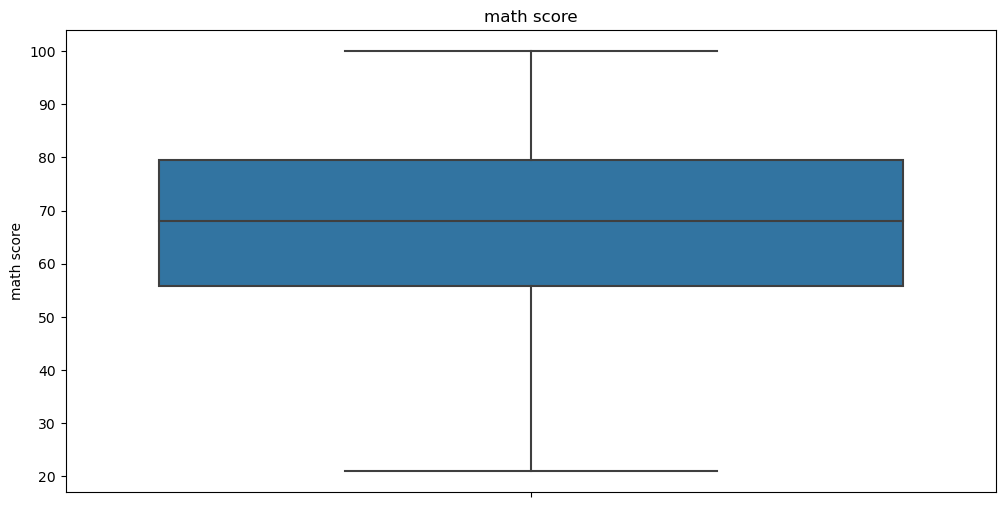

After removing outliers:
Dataframe with no outlier shape :(18, 8)


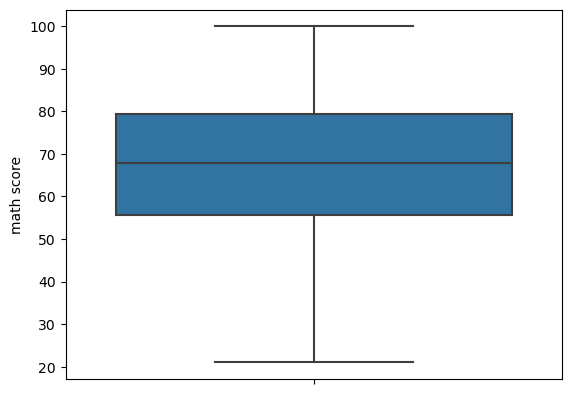

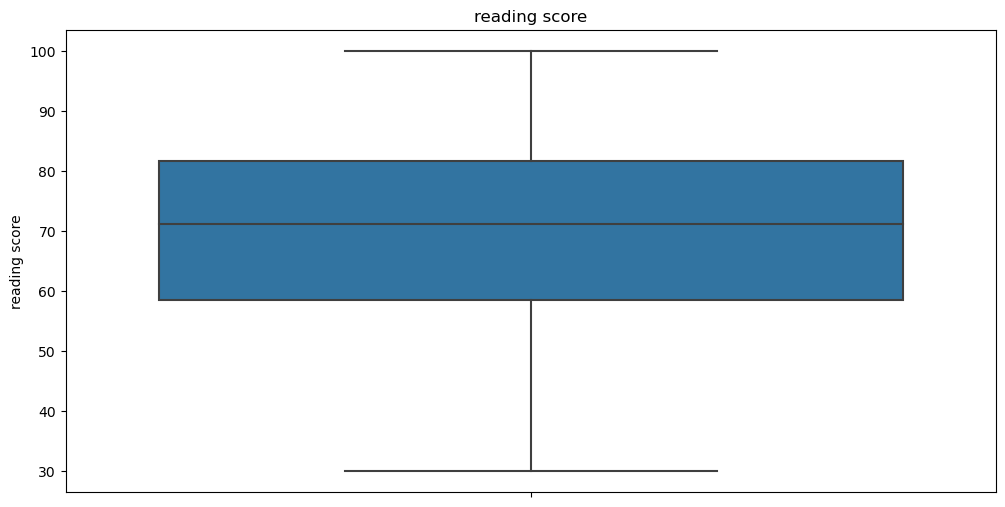

After removing outliers:
Dataframe with no outlier shape :(18, 8)


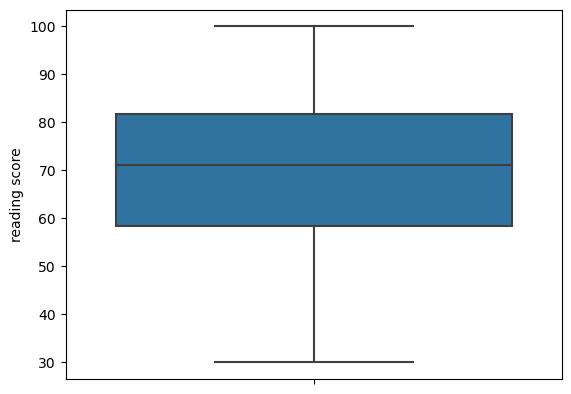

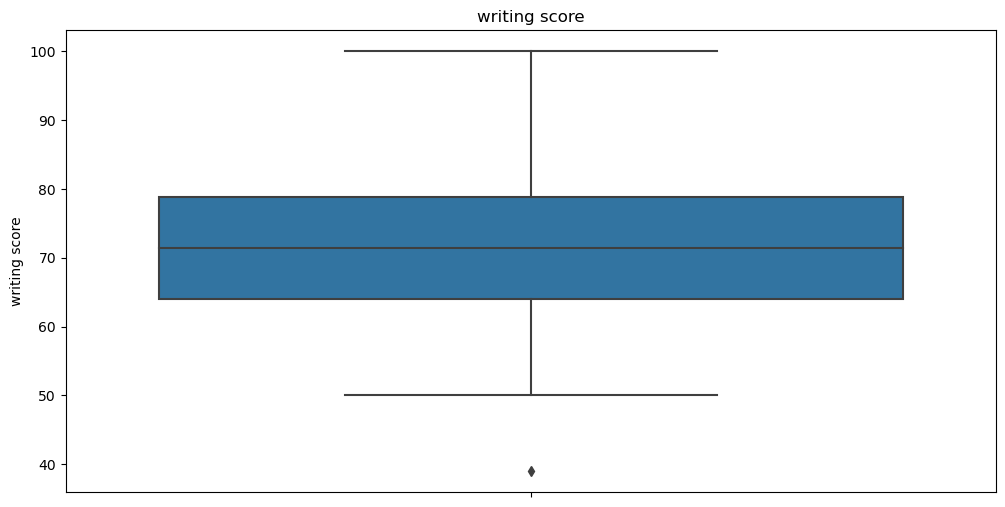

After removing outliers:
Dataframe with no outlier shape :(17, 8)


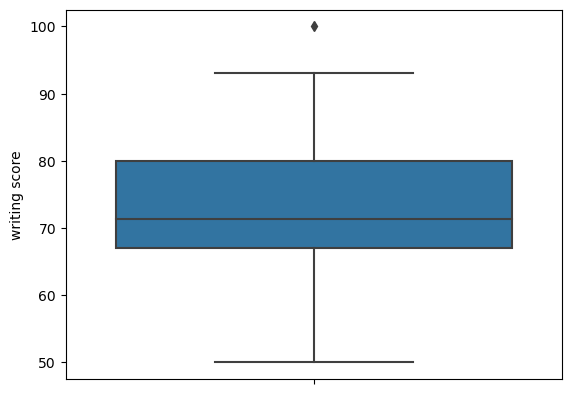

In [152]:
import seaborn as sns
import matplotlib.pyplot as plt
j=1;
scores=['math score','reading score','writing score']
for score in scores:
    plt.figure(figsize=(12,6))
    sns.boxplot(y=df[score])
    plt.title(score)
    plt.show()
    Q1=df[score].quantile(0.25)
    Q3=df[score].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    df_no_outliers=df[(df[score]>=lower_bound) & (df[score]<=upper_bound)]
    print("After removing outliers:");
    sns.boxplot(y=df_no_outliers[score])
    print(f"Dataframe with no outlier shape :{df_no_outliers.shape}")
    j=j+1

In [153]:
scores=['math score','reading score','writing score']
for score in scores:
    print(f" Skewness in {score} is {df[score].skew()}")

 Skewness in math score is -0.44861379874740226
 Skewness in reading score is -0.3123153088848672
 Skewness in writing score is -0.11965041587678674


In [154]:
#Z score Normalization 
#z=(x-mean())/std()
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df[scores]=scaler.fit_transform(df[scores])

In [155]:
df.head(5)

,gender,race,parental level of education,lunch,course_completion,math score,reading score,writing score
0,female,B,Bachelor,standard,no,0.248722,0.104469,0.175464
1,male,C,College,standard,yes,0.102816,0.007660,-0.088055
2,femle,A,High School,free/reduced,no,1.124155,1.386454,1.427179
3,female,B,Associate,standard,no,-0.967157,-0.731608,0.001076
4,male,D,High School,free/reduced,yes,0.443263,0.438900,0.241344
